# EMG Workshop

## Setup environment

In [54]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from scipy.io import loadmat

plt.ion()  # Turn on interactive mode

## Import data
1.	Load mvcr, mvcl, handr, and handl

In [55]:
path = r'C:\Users\MC99DK\OneDrive - Aalborg Universitet\Documents\DSP\moodle2'
mvcr = loadmat(path+'/mvcr.mat')
mvcr = mvcr['mvcr'].flatten()

mvcl = loadmat(path+'/mvcl.mat')
mvcl = mvcl['mvcl'].flatten()

handr = loadmat(path+'/handr.mat')
handr = handr['handr'].flatten()

handl = loadmat(path+'/handl.mat')
handl = handl['handl'].flatten()

## Filtering
### 2.	Remove offset from each of the 4 signals. Then calculate the filter coefficients Bn and An for 2 different Butterworth filters (bandpass and notch) and filter all 4 signals with both filters. 
(sampling frequency Fs is 1000 Hz)
A) Order = 2, cutoff = [10Hz 250Hz], bandpass
B) Order = 2, cutoff = [49Hz 51Hz], stop 


In [56]:
# Sampling frequency
fs = 1000

# --- Create Butterworth Filters ---

# A) Order = 2, cutoff = [10Hz, 250Hz], bandpass
sos_bp = signal.butter(2, [10, 250], btype='bandpass', fs=fs, output='sos')

# B) Order = 2, cutoff = [49Hz, 51Hz], stop (bandstop)
sos_st = signal.butter(2, [49, 51], btype='bandstop', fs=fs, output='sos')

# --- Detrend the Signals ---
mvcr = signal.detrend(mvcr)
mvcl = signal.detrend(mvcl)
handr = signal.detrend(handr)
handl = signal.detrend(handl)

# --- Apply the Filters ---
# Bandpass filter
mvcr = signal.sosfilt(sos_bp, mvcr)
mvcl = signal.sosfilt(sos_bp, mvcl)
handr = signal.sosfilt(sos_bp, handr)
handl = signal.sosfilt(sos_bp, handl)

# Bandstop filter
mvcr = signal.sosfilt(sos_st, mvcr)
mvcl = signal.sosfilt(sos_st, mvcl)
handr = signal.sosfilt(sos_st, handr)
handl = signal.sosfilt(sos_st, handl)

## Plot maximal voluntary contraction
### 3.	Create figure(1). Plot the filtered zero-mean signals: mvcr in green and mvcl in red colors with the time axis (t) given in seconds.

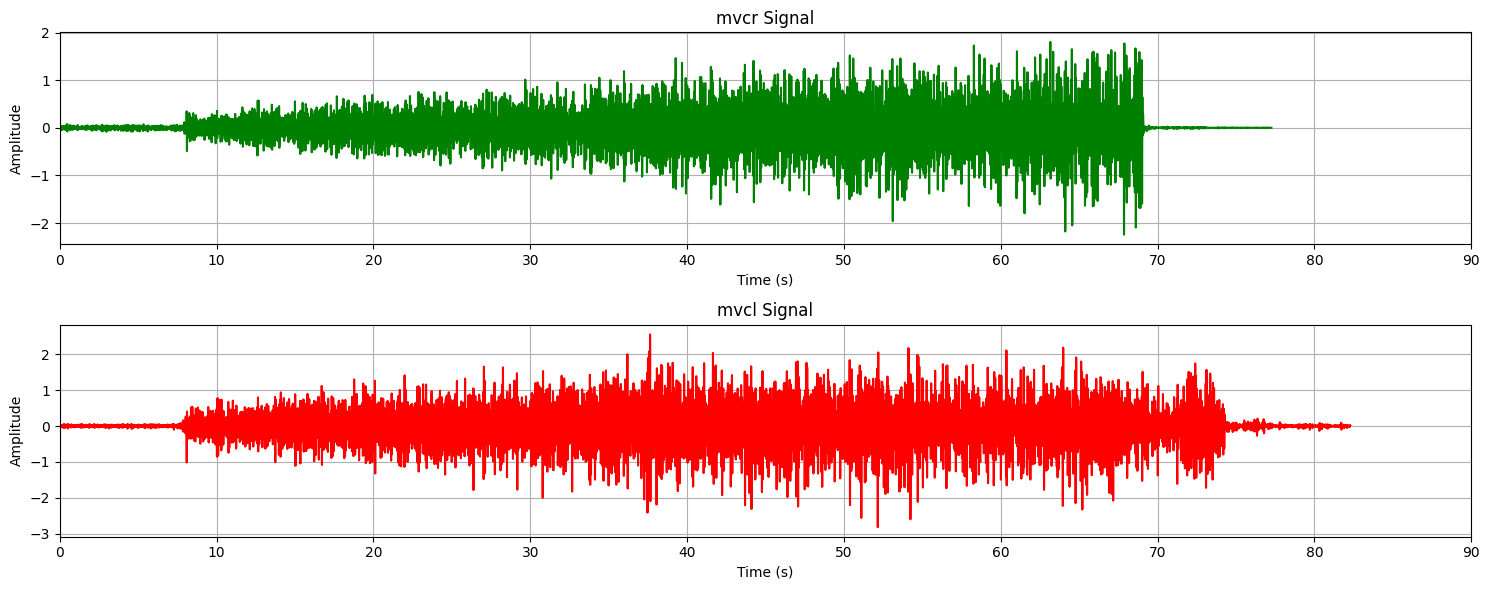

In [57]:
# Create time vectors
tr = np.linspace(0, len(mvcr) / fs, len(mvcr))
tl = np.linspace(0, len(mvcl) / fs, len(mvcl))

# Create a figure with two subplots
plt.figure(figsize=(15, 6))

# Plot mvcr in green
plt.subplot(2, 1, 1)
plt.plot(tr, mvcr, color='green')
plt.title('mvcr Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 90)

# Plot mvcl in red
plt.subplot(2, 1, 2)
plt.plot(tl, mvcl, color='red')
plt.title('mvcl Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.xlim(0, 90)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

#### 3a) What is the duration of the two recordings in seconds?

In [58]:
print("The duration of the two signals are:")
print(f"mvcr: {len(mvcr)/fs:.2f} seconds")
print(f"mvcl: {len(mvcl)/fs:.2f} seconds")

The duration of the two signals are:
mvcr: 77.26 seconds
mvcl: 82.29 seconds


#### 3b) How do the amplitudes of the recordings develop over time?
The amplitude is increasing over time (especially, for mvcr).
## Power spectra from start and end of the maximal contraction
### 4.	Calculate the power spectra for mvcr and mvcl for the time intervals 10-20 sec and 50-60 sec (10.000 samples). Normalize each of the 4 power spectra so they each have max amplitude 1.0. Create figure(2). Plot the normalized power spectra in black (mvcr 10-20 sec), green (mvcr 50-60 sec), black (mvcl 10-20 sec), and red (mvcl 50-60 sec). 

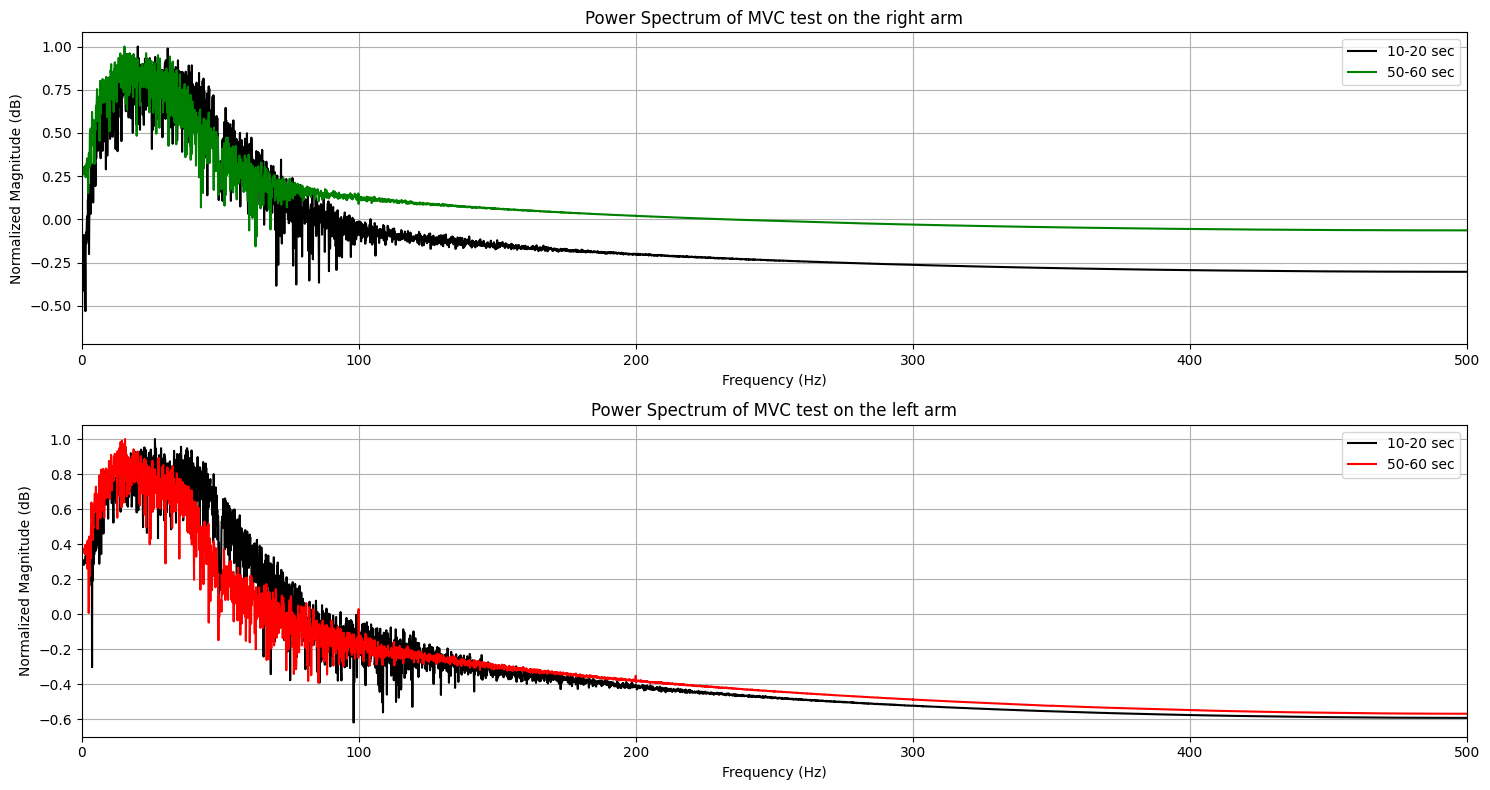

In [59]:
# Sampling frequency
fs = 1000

# Function to calculate FFT and normalize to dB
def calculate_fft_dB(sig, sampling_freq):
    N = len(sig)
    fft_vals = np.fft.fft(sig)
    dB_vals = 20 * np.log10(np.abs(fft_vals))
    dB_vals_normalized = dB_vals / np.max(dB_vals)
    freqs = np.linspace(0, sampling_freq, N)
    return freqs[:N//2], dB_vals_normalized[:N//2]  # Return only positive frequencies

# Extract time intervals
start_10, end_10 = 10, 20
start_50, end_50 = 50, 60

# Indices for the intervals
idx_10_20_mvcr = slice(int(start_10 * fs), int(end_10 * fs))
idx_50_60_mvcr = slice(int(start_50 * fs), int(end_50 * fs))

idx_10_20_mvcl = slice(int(start_10 * fs), int(end_10 * fs))
idx_50_60_mvcl = slice(int(start_50 * fs), int(end_50 * fs))

# Extract segments
mvcr10 = mvcr[idx_10_20_mvcr]
mvcr50 = mvcr[idx_50_60_mvcr]
mvcl10 = mvcl[idx_10_20_mvcl]
mvcl50 = mvcl[idx_50_60_mvcl]

# Calculate FFT and normalize to dB
f_r_10, fs_mvcr_10 = calculate_fft_dB(mvcr10, fs)
f_r_50, fs_mvcr_50 = calculate_fft_dB(mvcr50, fs)
f_l_10, fs_mvcl_10 = calculate_fft_dB(mvcl10, fs)
f_l_50, fs_mvcl_50 = calculate_fft_dB(mvcl50, fs)

# Create a figure with two subplots
plt.figure(figsize=(15, 8))

# Plot mvcr power spectra
plt.subplot(2, 1, 1)
plt.plot(f_r_10, fs_mvcr_10, color='black', label='10-20 sec')
plt.plot(f_r_50, fs_mvcr_50, color='green', label='50-60 sec')
plt.title('Power Spectrum of MVC test on the right arm')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Magnitude (dB)')
plt.legend()
plt.grid(True)
plt.xlim(0, 500)

# Plot mvcl power spectra
plt.subplot(2, 1, 2)
plt.plot(f_l_10, fs_mvcl_10, color='black', label='10-20 sec')
plt.plot(f_l_50, fs_mvcl_50, color='red', label='50-60 sec')
plt.title('Power Spectrum of MVC test on the left arm')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Normalized Magnitude (dB)')
plt.legend()
plt.grid(True)
plt.xlim(0, 500)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

#### 4a) What happens with the 2 power spectra for left and right lower arms as the time interval changes from 10-20 sec to 50-60 sec?
The power content is reduced in heigher frequencies, especially for the left arm; i.e., the power spectra are shifted towards lower frequencies, consistent with development of fatique.
## FFT calculation of fatigue
### 5.	Now calculate power spectra for mvcr and mvcl for each second (and 10 seconds forward, 10.000 samples, fx 1-11 sec, 2-12 sec and son on) of the signals as above. Normalize each power spectrum so max amplitude in the spectrum is 1.0. Then, calculate the median frequency of those values that are above 0.5 in each power spectrum. BE CAREFUL! Do not use the mirrored part of the power spectrum (the part >500 Hz) 

In [60]:
# Frequency axis
f = np.linspace(0, fs, 5000)

# Initialize list to store median frequencies
fs_mvc_r_medfreq = []
fs_mvc_l_medfreq = []

# Loop through the signals in 1-second steps
k = 0
for i in range(0, len(mvcr) - 10000, 1000):
    k += 1

    # 10 seconds of right arm signal
    mvc_r_i = mvcr[i:i+10000]

    # FFT of the 10 seconds
    fs_mvc_r_i = np.fft.fft(mvc_r_i)

    # dB of the 10 seconds
    dB_fs_mvc_r_i = 20 * np.log10(np.abs(fs_mvc_r_i))

    # Normalize so FFT has max value of 1.0
    dB_fs_mvc_r_i = dB_fs_mvc_r_i / np.max(dB_fs_mvc_r_i)

    # Find median frequency of values above 0.5 in the first 5000 values
    idx = np.where(dB_fs_mvc_r_i[:5000] > 0.5)[0]
    if len(idx) > 0:
        fs_mvc_r_medfreq.append(np.median(f[idx]))
    else:
        fs_mvc_r_medfreq.append(np.nan)  # Append NaN if no values above 0.5

    # 10 seconds of left arm signal
    mvc_l_i = mvcl[i:i+10000]

    # FFT of the 10 seconds
    fs_mvc_l_i = np.fft.fft(mvc_l_i)

    # dB of the 10 seconds
    dB_fs_mvc_l_i = 20 * np.log10(np.abs(fs_mvc_l_i))

    # Normalize so FFT has max value of 1.0
    dB_fs_mvc_l_i = dB_fs_mvc_l_i / np.max(dB_fs_mvc_l_i)

    # Find median frequency of values above 0.5 in the first 5000 values
    idx = np.where(dB_fs_mvc_l_i[:5000] > 0.5)[0]
    if len(idx) > 0:
        fs_mvc_l_medfreq.append(np.median(f[idx]))
    else:
        fs_mvc_l_medfreq.append(np.nan)  # Append NaN if no values above 0.5

# Convert lists to numpy arrays for easier handling
fs_mvc_r_medfreq = np.array(fs_mvc_r_medfreq)
fs_mvc_l_medfreq = np.array(fs_mvc_l_medfreq)

## FFT visualization of fatigue
### 6.	Create figure(3). Plot median frequencies from 5. 

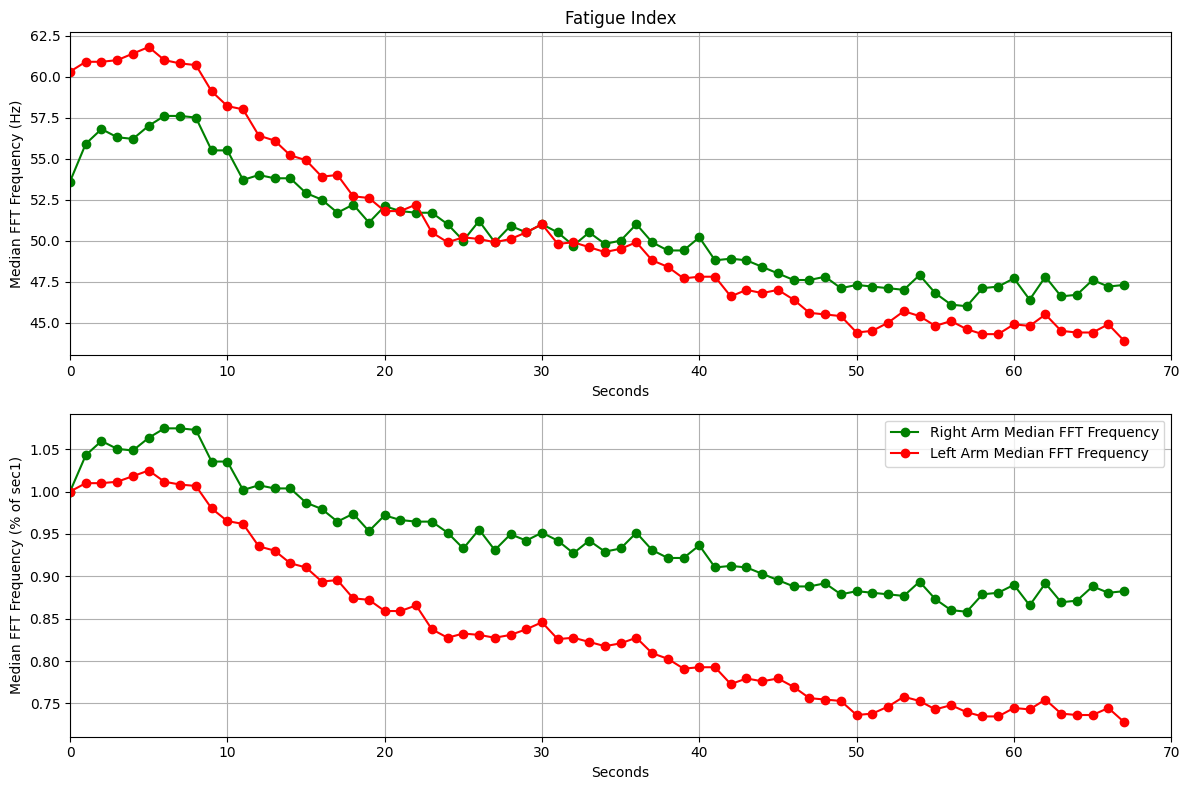

In [61]:
# Create a figure with two subplots
plt.figure(figsize=(12, 8))

# Top subplot: Original median frequencies
plt.subplot(2, 1, 1)
plt.plot(fs_mvc_r_medfreq, 'go-', label='Right Arm Median FFT Frequency')
plt.plot(fs_mvc_l_medfreq, 'ro-', label='Left Arm Median FFT Frequency')
plt.title('Fatigue Index')
plt.xlabel('Seconds')
plt.ylabel('Median FFT Frequency (Hz)')
plt.grid(True)
plt.xlim(0, 70)

# Bottom subplot: Normalized median frequencies
plt.subplot(2, 1, 2)
plt.plot(fs_mvc_r_medfreq / fs_mvc_r_medfreq[0], 'go-', label='Right Arm Median FFT Frequency')
plt.plot(fs_mvc_l_medfreq / fs_mvc_l_medfreq[0], 'ro-', label='Left Arm Median FFT Frequency')
plt.xlabel('Seconds')
plt.ylabel('Median FFT Frequency (% of sec1)')
plt.legend(loc='upper right')
plt.grid(True)
plt.xlim(0, 70)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

#### 6a) What happens with the frequency content of the EMG signal over time as the muscles fatigue?
The median frequencies gradually decline as the muscles fatigue. 
#### 6b) Which bicep muscle appears to fatigue faster – right or left?
The left biceps muscle appears to fatique faster than the right biceps.
## Plot grip-strength EMG
### 7.	Create a figure. Plot the filtered zero-mean signals: handr in cyan (’c’ ) and handl in green colors with time axis (t) given in seconds (sampling frequency Fs is 1000 Hz).

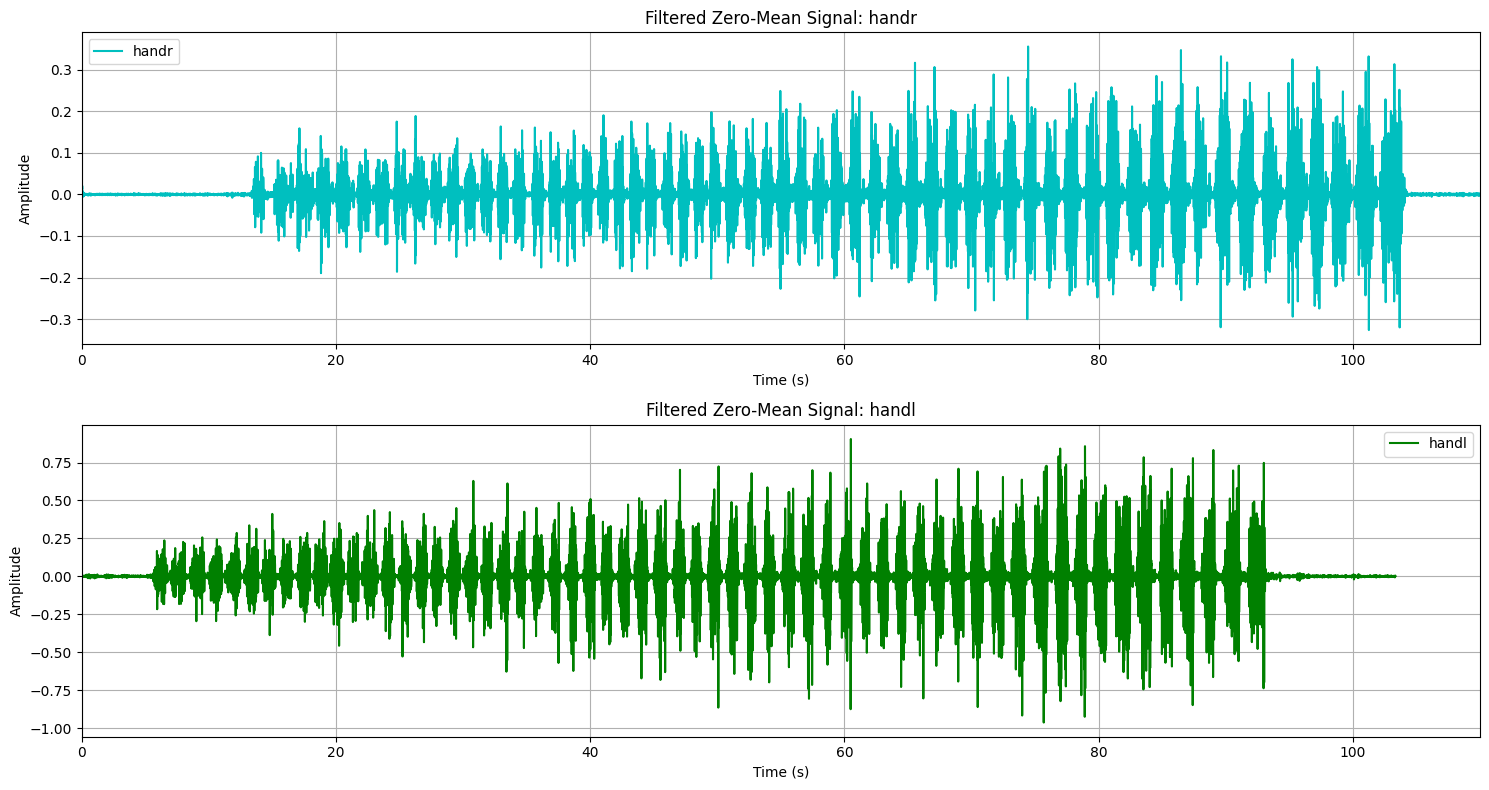

In [62]:
# Create time vectors
t_handr = np.linspace(0, len(handr) / fs, len(handr))
t_handl = np.linspace(0, len(handl) / fs, len(handl))

# Create a figure with two subplots
plt.figure(figsize=(15, 8))

# Plot handr in cyan
plt.subplot(2, 1, 1)
plt.plot(t_handr, handr, color='c', label='handr')
plt.title('Filtered Zero-Mean Signal: handr')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(0, 110)

# Plot handl in green
plt.subplot(2, 1, 2)
plt.plot(t_handl, handl, color='green', label='handl')
plt.title('Filtered Zero-Mean Signal: handl')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(0, 110)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

#### 7a) What is the duration of the recordings in seconds?


In [63]:
print("The duration of the two signals are:")
print(f"handr: {len(handr)/fs} seconds")
print(f"handl: {len(handl)/fs} seconds")

The duration of the two signals are:
handr: 110.63 seconds
handl: 103.348 seconds


#### 7b) How do the amplitudes change over time?
The amplitudes increase as the muscles fatique.
## Envelope for grip strength EMG
### 8.	Calculate the absolute values for the filtered handr and handl. Then, smooth the signals using a 50 point moving average filter. Finally, calculate rms values using a window length of 50 ms for both signals.

In [64]:
# Calculate the power of the signals
handr_power = signal.detrend(handr) ** 2
handl_power = signal.detrend(handl) ** 2

# Zero pad the power signals to allow for the moving average filter
pad_length = 50 // 2  # Half the window length for padding on each side
handr_power_padded = np.pad(handr_power, (pad_length, pad_length), mode='constant')
handl_power_padded = np.pad(handl_power, (pad_length, pad_length), mode='constant')

# Define the moving average function
def moving_average(x, w):
    return np.convolve(x, np.ones(w) / w, mode='valid')

# Calculate the moving average with a window length of 50 ms
window_length_samples = int(0.05 * fs)  # 50 ms window length in samples
handr_smoothed_power = moving_average(handr_power_padded, window_length_samples)
handl_smoothed_power = moving_average(handl_power_padded, window_length_samples)

# Calculate the RMS by taking the square root of the smoothed power
handr_rms = np.sqrt(handr_smoothed_power)
handl_rms = np.sqrt(handl_smoothed_power)

## Visualize envelopes for grip strength EMG
### 9.	Create a figure and plot the calculated envelopes in black on top of handr og handl.

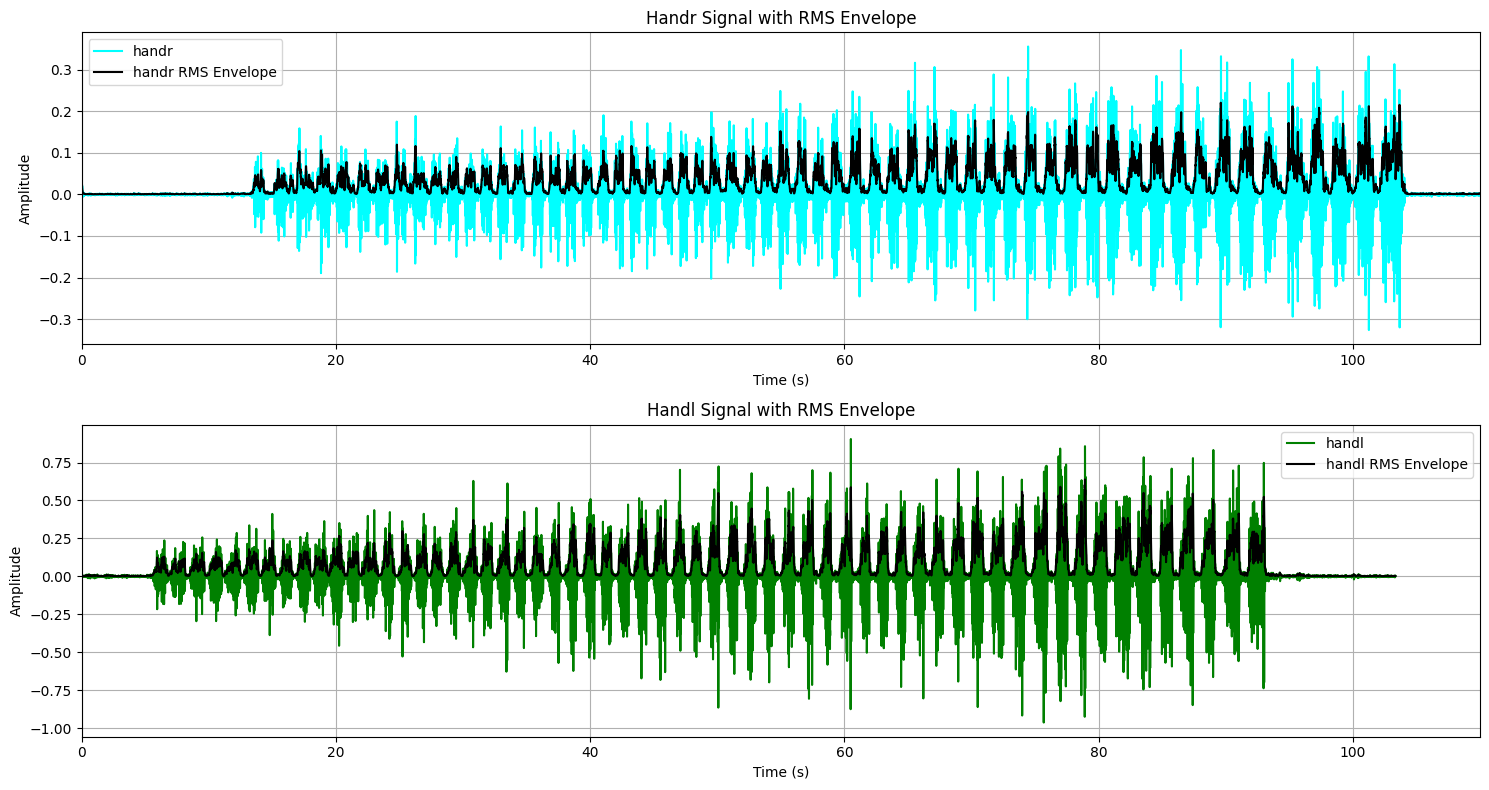

In [65]:
# Create a figure with two subplots
plt.figure(figsize=(15, 8))

# Time vectors for plotting
t_handr = np.linspace(0, len(handr) / fs, len(handr))
t_handr_rms = np.linspace(0, len(handr_rms) / fs, len(handr_rms))
t_handl = np.linspace(0, len(handl) / fs, len(handl))
t_handl_rms = np.linspace(0, len(handl_rms) / fs, len(handl_rms))


# Subplot for handr
plt.subplot(2, 1, 1)
plt.plot(t_handr, handr, color='cyan', label='handr')
plt.plot(t_handr_rms, handr_rms, color='black', label='handr RMS Envelope')
plt.title('Handr Signal with RMS Envelope')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(0, 110)

# Subplot for handl
plt.subplot(2, 1, 2)
plt.plot(t_handl, handl, color='green', label='handl')
plt.plot(t_handl_rms, handl_rms, color='black', label='handl RMS Envelope')
plt.title('Handl Signal with RMS Envelope')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.xlim(0, 110)

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plot
plt.show()

#### 9a) What would happen with the envelopes if more samples were used for smoothing and rms calculations?
The height of the envelopes would decrease while the width of each bump would increase, which could make it more challaging to detect the on- and offsets of muscle contractions because the slope would be more gradual and extend beyond where the muscles are activated. 